#  Pneumonia Detection - Lab 4

Ce notebook entraîne les 3 modèles (U-Net, ResNet, Inception) et génère les prédictions.

**Active le GPU** : Runtime → Change runtime type → GPU

## Installation et Setup

In [38]:
# Clone le repo
!git clone https://github.com/Mehyarmlaweh/Lab4-M2-IASD-app.git
%cd Lab4-M2-IASD-app

Cloning into 'Lab4-M2-IASD-app'...
remote: Enumerating objects: 5869, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 5869 (delta 6), reused 11 (delta 4), pack-reused 5854 (from 3)
Receiving objects: 100% (5869/5869), 1.13 GiB | 22.86 MiB/s, done.
Resolving deltas: 100% (8/8), done.
Updating files: 100% (5869/5869), done.
/content/Lab4-M2-IASD-app/Lab4-M2-IASD-app


In [39]:
# Installe les dépendances
!pip install -q torch torchvision scikit-learn matplotlib seaborn pandas numpy Pillow

## Définition des modèles

In [40]:
# U-Net
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        features = self.conv(x)
        pooled = self.pool(features)
        return features, pooled

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, base_filters=64, dropout_rate=0.5):
        super().__init__()
        f = base_filters

        self.enc1 = EncoderBlock(in_channels, f)
        self.enc2 = EncoderBlock(f, f * 2)
        self.enc3 = EncoderBlock(f * 2, f * 4)
        self.enc4 = EncoderBlock(f * 4, f * 8)

        self.bottleneck = DoubleConv(f * 8, f * 16)

        self.dec4 = DecoderBlock(f * 16, f * 8)
        self.dec3 = DecoderBlock(f * 8, f * 4)
        self.dec2 = DecoderBlock(f * 4, f * 2)
        self.dec1 = DecoderBlock(f * 2, f)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(f, 1)

    def forward(self, x):
        skip1, x = self.enc1(x)
        skip2, x = self.enc2(x)
        skip3, x = self.enc3(x)
        skip4, x = self.enc4(x)

        x = self.bottleneck(x)

        x = self.dec4(x, skip4)
        x = self.dec3(x, skip3)
        x = self.dec2(x, skip2)
        x = self.dec1(x, skip1)

        x = self.pool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.classifier(x)

print('U-Net défini')

U-Net défini


In [41]:
# ResNet
class ResidualBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.main = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.main(x)
        out = out + self.shortcut(x)
        return self.relu(out)

class ResNet(nn.Module):
    def __init__(self, in_channels=3, base_filters=64, dropout_rate=0.5):
        super().__init__()
        self.in_channels = base_filters

        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, base_filters, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(base_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.layer1 = self._make_layer(base_filters, n_blocks=2, stride=1)
        self.layer2 = self._make_layer(base_filters * 2, n_blocks=2, stride=2)
        self.layer3 = self._make_layer(base_filters * 4, n_blocks=2, stride=2)
        self.layer4 = self._make_layer(base_filters * 8, n_blocks=2, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(base_filters * 8, 1)

        self._init_weights()

    def _make_layer(self, out_channels, n_blocks, stride):
        layers = []
        layers.append(ResidualBlock(self.in_channels, out_channels, stride))
        self.in_channels = out_channels
        for _ in range(1, n_blocks):
            layers.append(ResidualBlock(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.classifier(x)

print('ResNet défini')

ResNet défini


In [42]:
# Inception
def conv_bn_relu(in_ch, out_ch, kernel, stride=1, padding=0):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=kernel, stride=stride, padding=padding, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, b1, b2_reduce, b2_out, b3_reduce, b3_out, b4_out):
        super().__init__()
        self.branch1 = conv_bn_relu(in_channels, b1, kernel=1)
        self.branch2 = nn.Sequential(
            conv_bn_relu(in_channels, b2_reduce, kernel=1),
            conv_bn_relu(b2_reduce, b2_out, kernel=3, padding=1),
        )
        self.branch3 = nn.Sequential(
            conv_bn_relu(in_channels, b3_reduce, kernel=1),
            conv_bn_relu(b3_reduce, b3_out, kernel=5, padding=2),
        )
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            conv_bn_relu(in_channels, b4_out, kernel=1),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)

class Inception(nn.Module):
    def __init__(self, in_channels=3, dropout_rate=0.5):
        super().__init__()
        self.stem = nn.Sequential(
            conv_bn_relu(in_channels, 32, kernel=3, stride=2, padding=1),
            conv_bn_relu(32, 64, kernel=3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        self.block1 = InceptionBlock(64, 32, 16, 32, 8, 16, 16)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.block2 = InceptionBlock(96, 64, 32, 64, 16, 32, 32)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.block3 = InceptionBlock(192, 96, 48, 96, 24, 48, 48)
        self.block4 = InceptionBlock(288, 96, 48, 96, 24, 48, 48)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(288, 1)

    def forward(self, x):
        x = self.stem(x)
        x = self.block1(x)
        x = self.pool1(x)
        x = self.block2(x)
        x = self.pool2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.classifier(x)

print('Inception défini')

Inception défini


In [43]:
class InceptionV2(nn.Module):
    def __init__(self, in_channels=3, dropout_rate=0.5):
        super().__init__()

        # Couche initiale pour extraction features bas niveau
        self.initial_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )

        # Stem
        self.stem = nn.Sequential(
            conv_bn_relu(32, 32, kernel=3, stride=2, padding=1),
            conv_bn_relu(32, 64, kernel=3, stride=1, padding=1),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )

        # Blocs Inception
        self.block1 = InceptionBlock(64, 32, 16, 32, 8, 16, 16)
        self.pool1 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.block2 = InceptionBlock(96, 64, 32, 64, 16, 32, 32)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.block3 = InceptionBlock(192, 96, 48, 96, 24, 48, 48)
        self.block4 = InceptionBlock(288, 96, 48, 96, 24, 48, 48)

        # Tete de classification
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(288, 1)

    def forward(self, x):
        x = self.initial_conv(x)
        x = self.stem(x)
        x = self.block1(x)
        x = self.pool1(x)
        x = self.block2(x)
        x = self.pool2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.pool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.classifier(x)

print('InceptionV2 defini')

InceptionV2 defini


## Fonctions d'entraînement et évaluation

In [44]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

def get_transforms(image_size=224, augment=False):
    normalize = transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    if augment:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            normalize,
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            normalize,
        ])

def get_dataloaders(image_size=224, batch_size=32):
    train_dataset = datasets.ImageFolder('data/train', transform=get_transforms(image_size, augment=True))
    val_dataset = datasets.ImageFolder('data/val', transform=get_transforms(image_size, augment=False))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    all_labels, all_probs = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        all_probs.extend(probs.flatten())
        all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = float(np.mean((np.array(all_probs) >= 0.5) == np.array(all_labels)))
    auc = roc_auc_score(all_labels, all_probs)

    return avg_loss, accuracy, auc

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_labels, all_probs = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)

            logits = model(images)
            loss = criterion(logits, labels)

            total_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())

    avg_loss = total_loss / len(loader.dataset)
    accuracy = float(np.mean((np.array(all_probs) >= 0.5) == np.array(all_labels)))
    auc = roc_auc_score(all_labels, all_probs)

    return avg_loss, accuracy, auc

def train_model(model, model_name, epochs=10, lr=1e-3, batch_size=32, image_size=224):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'\nEntraînement {model_name} sur {device}')
    print(f'   Epochs: {epochs}, LR: {lr}, Batch: {batch_size}, Image: {image_size}x{image_size}')

    model = model.to(device)
    train_loader, val_loader = get_dataloaders(image_size, batch_size)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()

    history = {
        'train_losses': [], 'val_losses': [],
        'train_accs': [], 'val_accs': [],
        'train_aucs': [], 'val_aucs': []
    }

    best_val_auc = 0.0

    for epoch in range(epochs):
        tr_loss, tr_acc, tr_auc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, vl_auc = evaluate(model, val_loader, criterion, device)

        history['train_losses'].append(tr_loss)
        history['val_losses'].append(vl_loss)
        history['train_accs'].append(tr_acc)
        history['val_accs'].append(vl_acc)
        history['train_aucs'].append(tr_auc)
        history['val_aucs'].append(vl_auc)

        if vl_auc > best_val_auc:
            best_val_auc = vl_auc
            torch.save(model.state_dict(), f'{model_name}_best.pt')

        print(f'Epoch {epoch+1}/{epochs} | '
              f'Train: loss={tr_loss:.4f} acc={tr_acc:.4f} auc={tr_auc:.4f} | '
              f'Val: loss={vl_loss:.4f} acc={vl_acc:.4f} auc={vl_auc:.4f}')

    print(f'\nBest Val AUC: {best_val_auc:.4f}')
    return history, best_val_auc

def plot_curves(history, model_name):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs_range = range(1, len(history['train_losses']) + 1)

    axes[0].plot(epochs_range, history['train_losses'], 'o-', label='Train')
    axes[0].plot(epochs_range, history['val_losses'], 's-', label='Val')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_range, history['train_accs'], 'o-', label='Train')
    axes[1].plot(epochs_range, history['val_accs'], 's-', label='Val')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(epochs_range, history['train_aucs'], 'o-', label='Train')
    axes[2].plot(epochs_range, history['val_aucs'], 's-', label='Val')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('AUC')
    axes[2].set_title('ROC-AUC')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    fig.suptitle(f'{model_name} — Training curves', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('Fonctions définies')

Fonctions définies


##  Entraînement des modèles

On entraîne les 3 modèles avec des hyperparamètres optimisés pour GPU.

In [47]:
# Hyperparamètres
EPOCHS = 15
LR = 1e-3
BATCH_SIZE = 32
IMAGE_SIZE = 224

results = {}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda



Entraînement U-Net sur cuda
   Epochs: 15, LR: 0.001, Batch: 32, Image: 224x224
Epoch 1/15 | Train: loss=0.3541 acc=0.8415 auc=0.9015 | Val: loss=0.4663 acc=0.8125 auc=0.8438
Epoch 2/15 | Train: loss=0.2074 acc=0.9181 auc=0.9661 | Val: loss=1.9262 acc=0.5625 auc=0.9531
Epoch 3/15 | Train: loss=0.1734 acc=0.9324 auc=0.9756 | Val: loss=0.3916 acc=0.8125 auc=0.9375
Epoch 4/15 | Train: loss=0.1584 acc=0.9411 auc=0.9794 | Val: loss=0.5704 acc=0.7500 auc=0.8281
Epoch 5/15 | Train: loss=0.1568 acc=0.9407 auc=0.9798 | Val: loss=1.2194 acc=0.5625 auc=0.9375
Epoch 6/15 | Train: loss=0.1470 acc=0.9460 auc=0.9818 | Val: loss=1.3714 acc=0.5625 auc=0.8594
Epoch 7/15 | Train: loss=0.1440 acc=0.9478 auc=0.9827 | Val: loss=1.6961 acc=0.5625 auc=0.9062
Epoch 8/15 | Train: loss=0.1333 acc=0.9507 auc=0.9852 | Val: loss=1.0120 acc=0.5625 auc=1.0000
Epoch 9/15 | Train: loss=0.1328 acc=0.9510 auc=0.9852 | Val: loss=0.8682 acc=0.6250 auc=0.9688
Epoch 10/15 | Train: loss=0.1227 acc=0.9535 auc=0.9876 | Val: lo

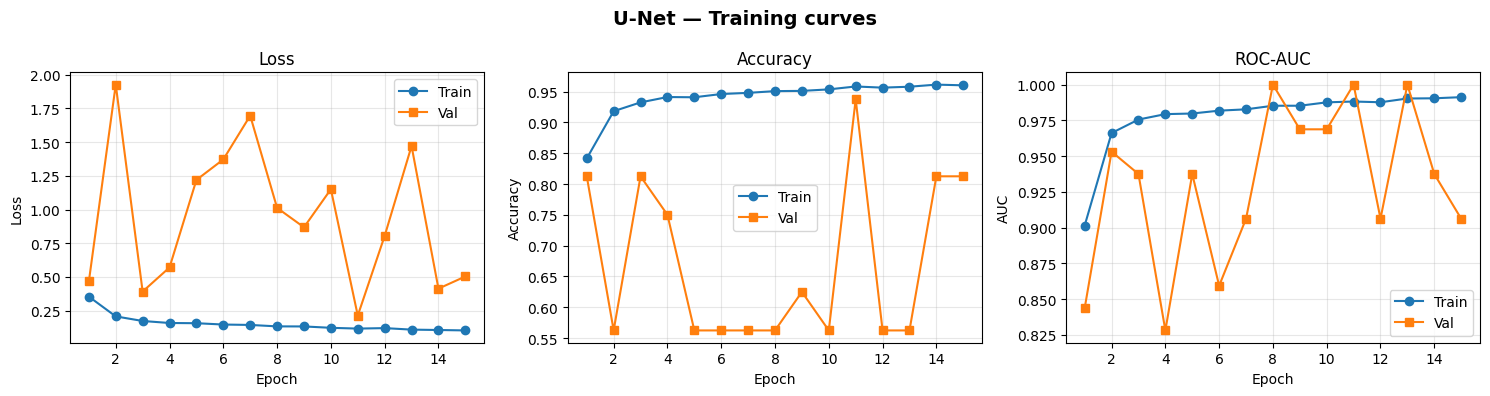

In [48]:
# Entraîne U-Net
unet = UNet(in_channels=3, dropout_rate=0.5)
history_unet, auc_unet = train_model(unet, 'U-Net', EPOCHS, LR, BATCH_SIZE, IMAGE_SIZE)
results['U-Net'] = {'history': history_unet, 'best_auc': auc_unet}
plot_curves(history_unet, 'U-Net')


Entraînement ResNet sur cuda
   Epochs: 15, LR: 0.001, Batch: 32, Image: 224x224
Epoch 1/15 | Train: loss=0.2825 acc=0.8799 auc=0.9368 | Val: loss=2.3434 acc=0.5625 auc=0.7031
Epoch 2/15 | Train: loss=0.1687 acc=0.9354 auc=0.9764 | Val: loss=0.4188 acc=0.8750 auc=0.9062
Epoch 3/15 | Train: loss=0.1439 acc=0.9465 auc=0.9823 | Val: loss=1.2621 acc=0.7500 auc=0.8281
Epoch 4/15 | Train: loss=0.1314 acc=0.9512 auc=0.9856 | Val: loss=0.3147 acc=0.8750 auc=0.9219
Epoch 5/15 | Train: loss=0.1153 acc=0.9565 auc=0.9889 | Val: loss=1.3108 acc=0.7500 auc=0.8594
Epoch 6/15 | Train: loss=0.1132 acc=0.9595 auc=0.9891 | Val: loss=0.2648 acc=0.8750 auc=0.9531
Epoch 7/15 | Train: loss=0.1027 acc=0.9623 auc=0.9909 | Val: loss=0.4734 acc=0.7500 auc=0.9375
Epoch 8/15 | Train: loss=0.1009 acc=0.9616 auc=0.9912 | Val: loss=0.3769 acc=0.8125 auc=0.9219
Epoch 9/15 | Train: loss=0.0879 acc=0.9691 auc=0.9932 | Val: loss=0.2718 acc=0.8750 auc=1.0000
Epoch 10/15 | Train: loss=0.0937 acc=0.9665 auc=0.9925 | Val: l

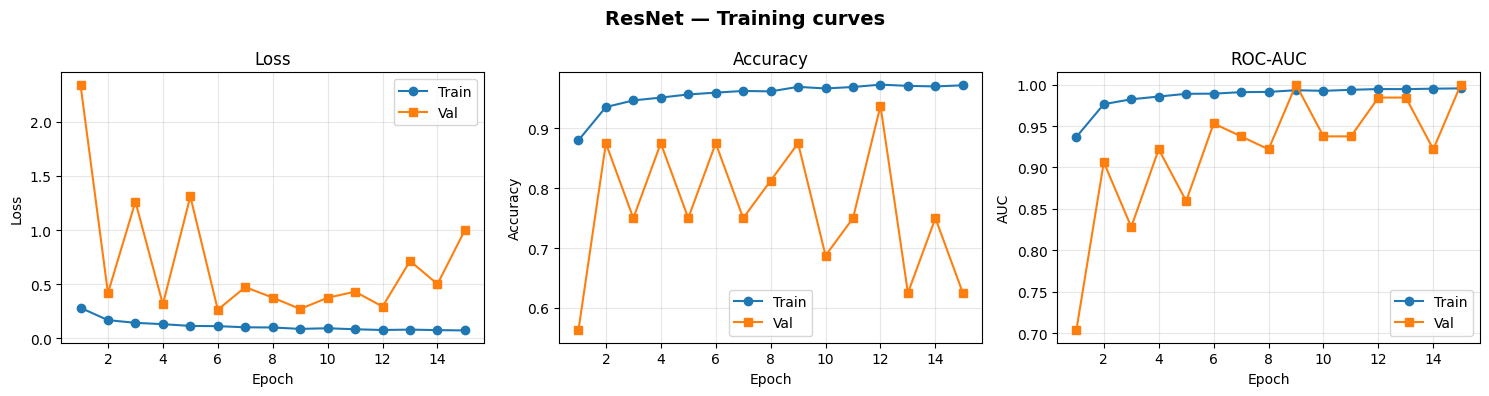

In [49]:
# Entraîne ResNet
resnet = ResNet(in_channels=3, dropout_rate=0.5)
history_resnet, auc_resnet = train_model(resnet, 'ResNet', EPOCHS, LR, BATCH_SIZE, IMAGE_SIZE)
results['ResNet'] = {'history': history_resnet, 'best_auc': auc_resnet}
plot_curves(history_resnet, 'ResNet')


Entraînement Inception sur cuda
   Epochs: 15, LR: 0.001, Batch: 32, Image: 224x224
Epoch 1/15 | Train: loss=0.2338 acc=0.9057 auc=0.9578 | Val: loss=0.4129 acc=0.8750 auc=0.8750
Epoch 2/15 | Train: loss=0.1487 acc=0.9413 auc=0.9820 | Val: loss=1.5071 acc=0.5625 auc=0.9219
Epoch 3/15 | Train: loss=0.1159 acc=0.9554 auc=0.9885 | Val: loss=1.2753 acc=0.5625 auc=0.9375
Epoch 4/15 | Train: loss=0.1062 acc=0.9610 auc=0.9904 | Val: loss=0.7183 acc=0.7500 auc=0.9062
Epoch 5/15 | Train: loss=0.0923 acc=0.9657 auc=0.9927 | Val: loss=1.9275 acc=0.5625 auc=0.8125
Epoch 6/15 | Train: loss=0.1035 acc=0.9603 auc=0.9909 | Val: loss=1.5453 acc=0.6250 auc=0.8750
Epoch 7/15 | Train: loss=0.0838 acc=0.9661 auc=0.9938 | Val: loss=0.2741 acc=0.8125 auc=1.0000
Epoch 8/15 | Train: loss=0.0870 acc=0.9655 auc=0.9935 | Val: loss=0.6111 acc=0.6875 auc=1.0000
Epoch 9/15 | Train: loss=0.0877 acc=0.9669 auc=0.9931 | Val: loss=0.4764 acc=0.7500 auc=1.0000
Epoch 10/15 | Train: loss=0.0711 acc=0.9750 auc=0.9957 | Val

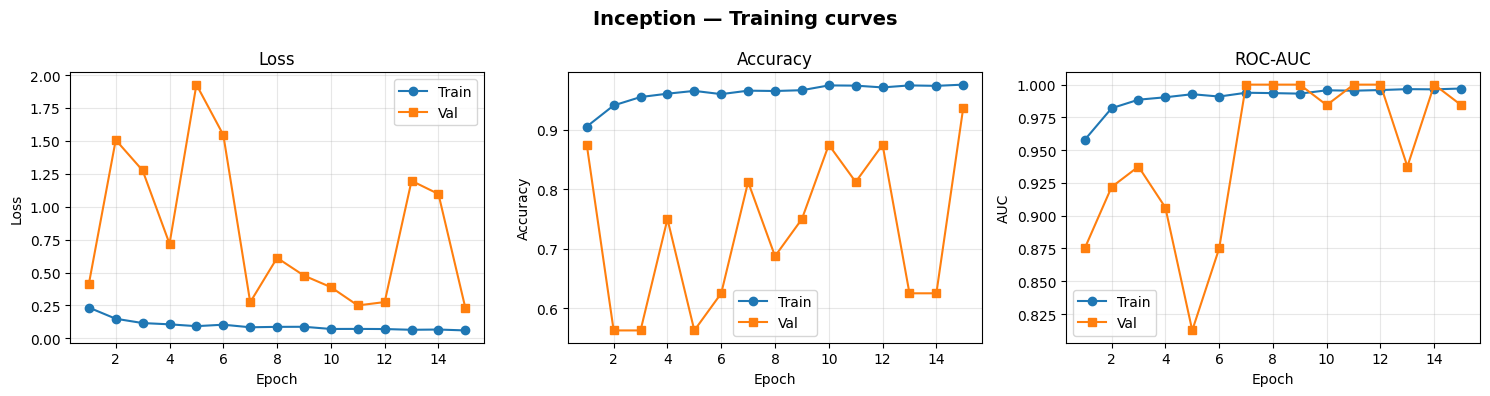

In [50]:
# Entraîne Inception
inception = Inception(in_channels=3, dropout_rate=0.5)
history_inception, auc_inception = train_model(inception, 'Inception', EPOCHS, LR, BATCH_SIZE, IMAGE_SIZE)
results['Inception'] = {'history': history_inception, 'best_auc': auc_inception}
plot_curves(history_inception, 'Inception')


Entraînement InceptionV2 sur cuda
   Epochs: 15, LR: 0.001, Batch: 32, Image: 224x224
Epoch 1/15 | Train: loss=0.2369 acc=0.9000 auc=0.9566 | Val: loss=1.7192 acc=0.5625 auc=0.7344
Epoch 2/15 | Train: loss=0.1386 acc=0.9467 auc=0.9844 | Val: loss=1.5397 acc=0.5625 auc=0.8750
Epoch 3/15 | Train: loss=0.1254 acc=0.9527 auc=0.9870 | Val: loss=0.9843 acc=0.7500 auc=0.7969
Epoch 4/15 | Train: loss=0.1030 acc=0.9608 auc=0.9912 | Val: loss=0.8118 acc=0.6875 auc=0.8906
Epoch 5/15 | Train: loss=0.0982 acc=0.9593 auc=0.9924 | Val: loss=0.8710 acc=0.6875 auc=0.8750
Epoch 6/15 | Train: loss=0.0927 acc=0.9655 auc=0.9925 | Val: loss=0.7297 acc=0.7500 auc=0.8906
Epoch 7/15 | Train: loss=0.0917 acc=0.9648 auc=0.9931 | Val: loss=0.6108 acc=0.6875 auc=0.9219
Epoch 8/15 | Train: loss=0.0894 acc=0.9659 auc=0.9932 | Val: loss=2.3793 acc=0.5000 auc=0.9531
Epoch 9/15 | Train: loss=0.0809 acc=0.9682 auc=0.9945 | Val: loss=0.9320 acc=0.6875 auc=0.8750
Epoch 10/15 | Train: loss=0.0764 acc=0.9703 auc=0.9951 | V

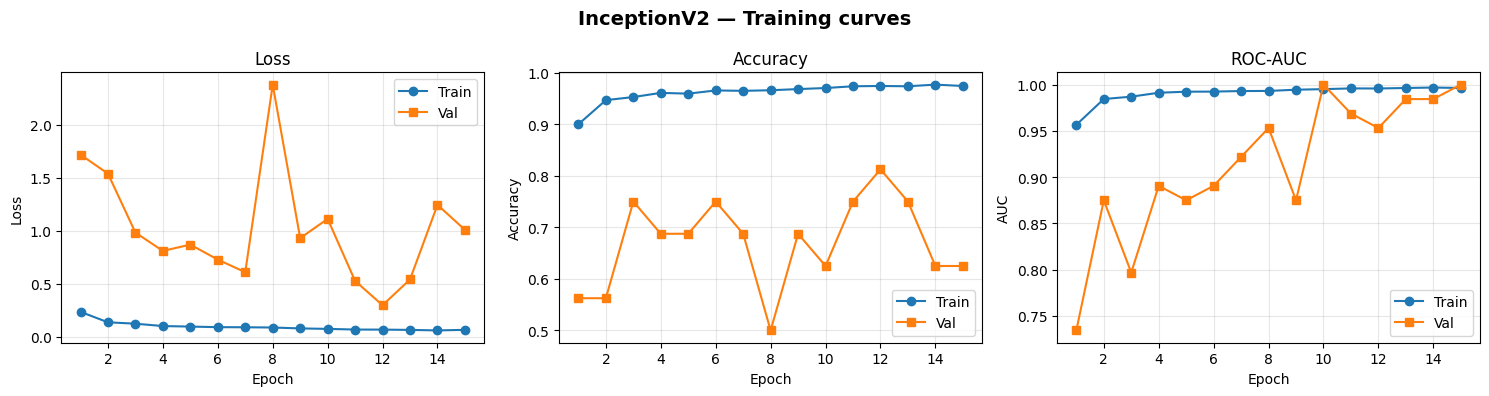


COMPARAISON V1 vs V2
Inception V1 (original): AUC = 1.0000
Inception V2 (+ conv):   AUC = 1.0000
Difference:              +0.0000


In [51]:
# Entraine Inception V2
inception_v2 = InceptionV2(in_channels=3, dropout_rate=0.5)
history_v2, auc_v2 = train_model(inception_v2, 'InceptionV2', EPOCHS, LR, BATCH_SIZE, IMAGE_SIZE)
plot_curves(history_v2, 'InceptionV2')
results['InceptionV2'] = {'history': history_v2, 'best_auc': auc_v2}
# Compare avec V1
print(f'\n{"="*80}')
print(f'COMPARAISON V1 vs V2')
print(f'{"="*80}')
print(f'Inception V1 (original): AUC = 1.0000')
print(f'Inception V2 (+ conv):   AUC = {auc_v2:.4f}')
print(f'Difference:              {auc_v2 - 1.0000:+.4f}')
print(f'{"="*80}')

Comparaison des résultats

In [52]:
import pandas as pd

comparison = pd.DataFrame([
    {'Model': name, 'Best Val AUC': data['best_auc']}
    for name, data in results.items()
]).sort_values('Best Val AUC', ascending=False)

print('\nClassement des modèles:')
print(comparison.to_string(index=False))

best_model = comparison.iloc[0]['Model']
print(f'\nMeilleur modèle: {best_model}')


Classement des modèles:
      Model  Best Val AUC
      U-Net           1.0
     ResNet           1.0
  Inception           1.0
InceptionV2           1.0

Meilleur modèle: U-Net


## Génération des prédictions

On utilise le meilleur modèle pour générer les prédictions sur le test set.

In [53]:
from pathlib import Path
from PIL import Image

# Charge le modele
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_model = "InceptionV2"

if best_model == 'U-Net':
    model = UNet(in_channels=3).to(device)
elif best_model == 'ResNet':
    model = ResNet(in_channels=3).to(device)
elif best_model == 'Inception':
    model = Inception(in_channels=3).to(device)
else:
    model = InceptionV2(in_channels=3).to(device)

model.load_state_dict(torch.load(f'{best_model}_best.pt', map_location=device))
model.eval()

# Charge les images de test
transform = get_transforms(IMAGE_SIZE, augment=False)
test_dir = Path('submission/test_for_students')
image_paths = sorted(test_dir.glob('*.jpeg')) + sorted(test_dir.glob('*.jpg')) + sorted(test_dir.glob('*.png'))

print(f'Images trouvees: {len(image_paths)}')

# Predictions
predictions = []
with torch.no_grad():
    for i, img_path in enumerate(image_paths):
        if i % 50 == 0:
            print(f'{i}/{len(image_paths)}...')

        image = Image.open(img_path).convert('RGB')
        tensor = transform(image).unsqueeze(0).to(device)
        logit = model(tensor)
        prob = torch.sigmoid(logit).item()
        predictions.append({'id': img_path.stem, 'prediction': prob})

# Sauvegarde
submission_df = pd.DataFrame(predictions)
submission_df.to_csv('submission.csv', index=False)

print(f'\nFichier cree: submission.csv ({len(submission_df)} predictions)')
print(submission_df.head(10))

Images trouvees: 529
0/529...
50/529...
100/529...
150/529...
200/529...
250/529...
300/529...
350/529...
400/529...
450/529...
500/529...

Fichier cree: submission.csv (529 predictions)
        id  prediction
0  img_001    0.999992
1  img_002    0.196140
2  img_003    0.254658
3  img_004    0.303388
4  img_005    0.999997
5  img_006    0.999993
6  img_007    0.999966
7  img_008    0.020033
8  img_009    0.999998
9  img_010    0.999999


## Télécharge le fichier de soumission

Clique sur le fichier `submission.csv` dans le panneau de gauche et télécharge-le pour le soumettre au leaderboard !

In [54]:
# Télécharge automatiquement le fichier (dans Colab)
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

COMPARAISON DES 4 MODELES SUR VALIDATION

Images: 16
Classes: ['NORMAL', 'PNEUMONIA']


TEST U-Net

RESULTATS U-Net
----------------------------------------
AUC:      1.0000
Accuracy: 0.5625

Confusion Matrix:
           Pred NORMAL  Pred PNEUMO
NORMAL            1            7
PNEUMO            0            8

Probabilites moyennes:
  NORMAL:    0.775
  PNEUMONIA: 0.987

Erreurs: 7/16 (43.8%)

TEST ResNet

RESULTATS ResNet
----------------------------------------
AUC:      1.0000
Accuracy: 0.8750

Confusion Matrix:
           Pred NORMAL  Pred PNEUMO
NORMAL            6            2
PNEUMO            0            8

Probabilites moyennes:
  NORMAL:    0.341
  PNEUMONIA: 0.964

Erreurs: 2/16 (12.5%)

TEST Inception

RESULTATS Inception
----------------------------------------
AUC:      1.0000
Accuracy: 0.8125

Confusion Matrix:
           Pred NORMAL  Pred PNEUMO
NORMAL            5            3
PNEUMO            0            8

Probabilites moyennes:
  NORMAL:    0.316
  PNEUMONIA: 0.

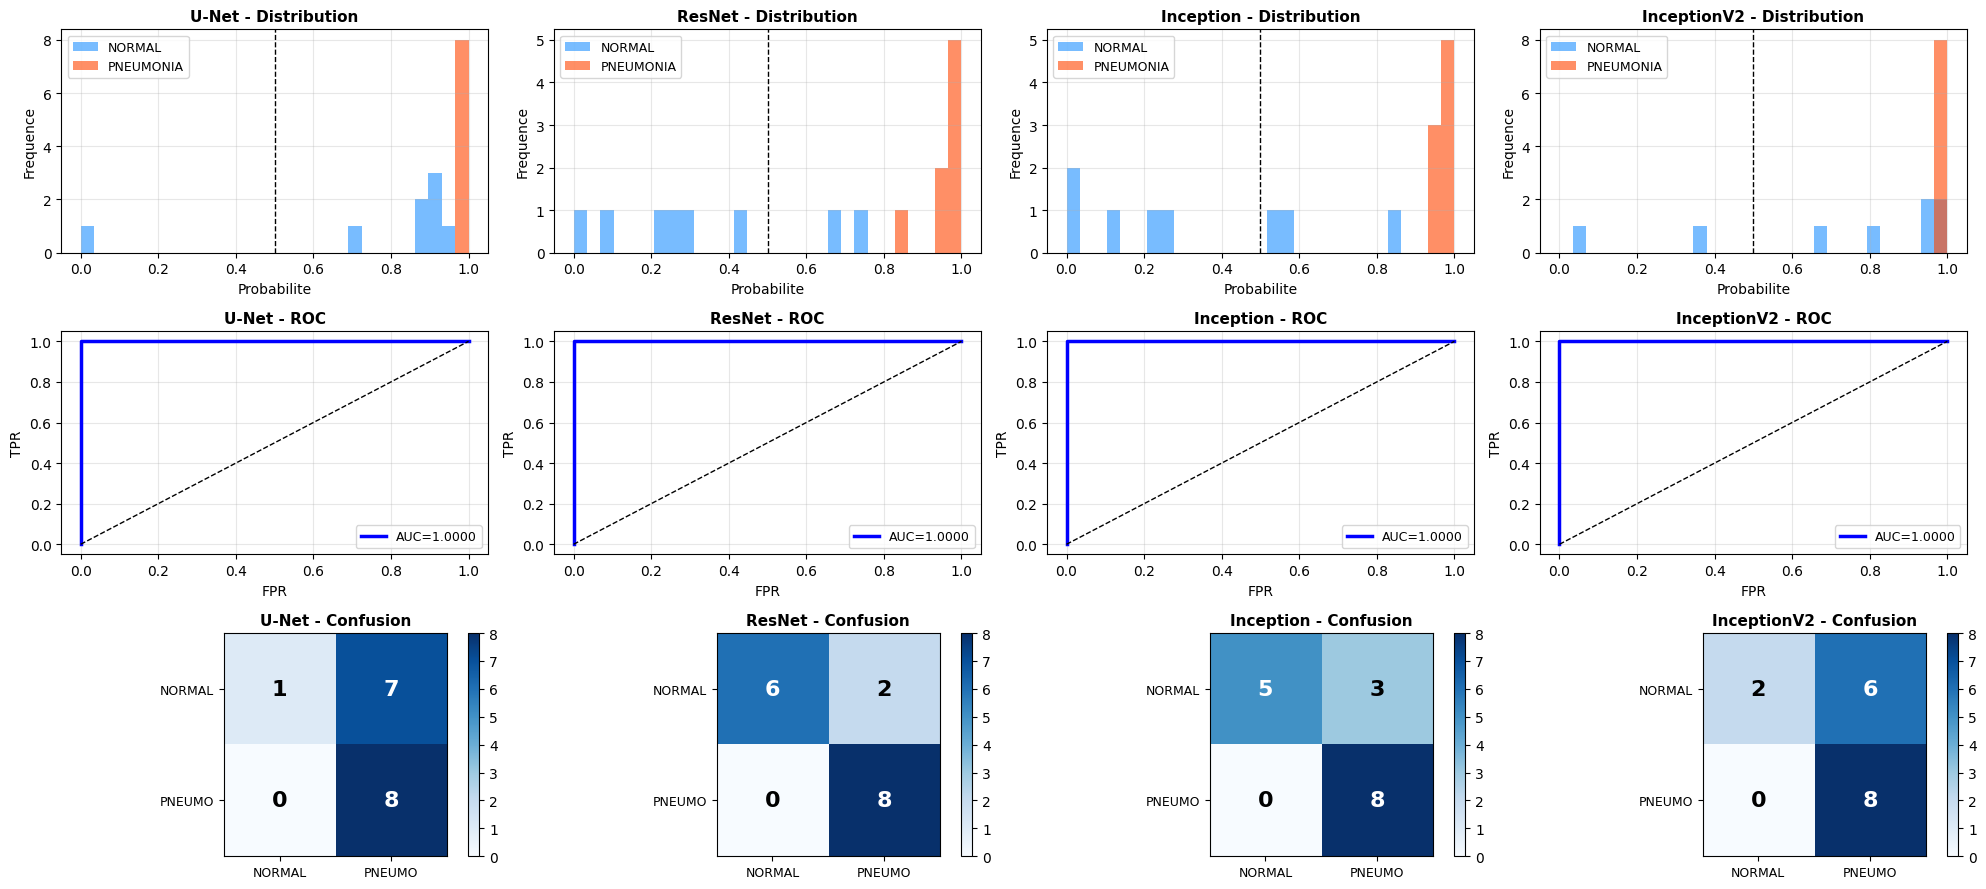


TABLEAU RECAPITULATIF

     Modele  AUC  Accuracy  Erreurs  Total
      U-Net  1.0    0.5625        7     16
     ResNet  1.0    0.8750        2     16
  Inception  1.0    0.8125        3     16
InceptionV2  1.0    0.6250        6     16

MEILLEUR MODELE: U-Net (AUC=1.0000)


In [55]:
# =============================================================================
# TEST DES 4 MODELES SUR VALIDATION
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
import numpy as np

print("="*80)
print("COMPARAISON DES 4 MODELES SUR VALIDATION")
print("="*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Charge validation
transform = get_transforms(224, augment=False)
val_dataset = datasets.ImageFolder('data/val', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"\nImages: {len(val_dataset)}")
print(f"Classes: {val_dataset.classes}\n")

# Charge les 4 modeles
models = {
    'U-Net': UNet(in_channels=3, dropout_rate=0.5),
    'ResNet': ResNet(in_channels=3, dropout_rate=0.5),
    'Inception': Inception(in_channels=3, dropout_rate=0.5),
    'InceptionV2': InceptionV2(in_channels=3, dropout_rate=0.5)
}

results = {}

for model_name, model in models.items():
    print(f"\n{'='*80}")
    print(f"TEST {model_name}")
    print(f"{'='*80}")

    # Charge les poids
    try:
        model.load_state_dict(torch.load(f'{model_name}_best.pt', map_location=device))
        model = model.to(device)
        model.eval()
    except FileNotFoundError:
        print(f"ERREUR: {model_name}_best.pt introuvable")
        continue

    # Predictions
    labels, probs = [], []

    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            p = torch.sigmoid(logits).cpu().numpy().flatten()

            labels.extend(lbls.numpy())
            probs.extend(p)

    labels = np.array(labels)
    probs = np.array(probs)

    # Metriques
    auc = roc_auc_score(labels, probs)
    preds = (probs >= 0.5).astype(int)
    acc = np.mean(preds == labels)
    cm = confusion_matrix(labels, preds)

    # Stats par classe
    normal_p = probs[labels == 0]
    pneumo_p = probs[labels == 1]

    # Stocke
    results[model_name] = {
        'labels': labels,
        'probs': probs,
        'auc': auc,
        'acc': acc,
        'cm': cm,
        'normal_p': normal_p,
        'pneumo_p': pneumo_p
    }

    # Affiche
    print(f"\nRESULTATS {model_name}")
    print("-"*40)
    print(f"AUC:      {auc:.4f}")
    print(f"Accuracy: {acc:.4f}")
    print(f"\nConfusion Matrix:")
    print(f"           Pred NORMAL  Pred PNEUMO")
    print(f"NORMAL          {cm[0,0]:3d}          {cm[0,1]:3d}")
    print(f"PNEUMO          {cm[1,0]:3d}          {cm[1,1]:3d}")
    print(f"\nProbabilites moyennes:")
    print(f"  NORMAL:    {normal_p.mean():.3f}")
    print(f"  PNEUMONIA: {pneumo_p.mean():.3f}")

    # Erreurs
    errors = np.where(preds != labels)[0]
    print(f"\nErreurs: {len(errors)}/{len(labels)} ({100*len(errors)/len(labels):.1f}%)")


# =============================================================================
# COMPARAISON VISUELLE
# =============================================================================

print(f"\n{'='*80}")
print("COMPARAISON VISUELLE")
print(f"{'='*80}")

fig = plt.figure(figsize=(20, 9))

# Ligne 1: Distributions
for i, (name, res) in enumerate(results.items()):
    ax = plt.subplot(3, 4, i+1)
    bins = np.linspace(0, 1, 30)

    plt.hist(res['normal_p'], bins=bins, alpha=0.6, label='NORMAL', color='dodgerblue')
    plt.hist(res['pneumo_p'], bins=bins, alpha=0.6, label='PNEUMONIA', color='orangered')
    plt.axvline(0.5, color='black', linestyle='--', linewidth=1)
    plt.xlabel('Probabilite', fontsize=10)
    plt.ylabel('Frequence', fontsize=10)
    plt.title(f'{name} - Distribution', fontweight='bold', fontsize=11)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)

# Ligne 2: ROC Curves
for i, (name, res) in enumerate(results.items()):
    ax = plt.subplot(3, 4, i+5)
    fpr, tpr, _ = roc_curve(res['labels'], res['probs'])
    plt.plot(fpr, tpr, 'b-', linewidth=2.5, label=f'AUC={res["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('FPR', fontsize=10)
    plt.ylabel('TPR', fontsize=10)
    plt.title(f'{name} - ROC', fontweight='bold', fontsize=11)
    plt.legend(fontsize=9)
    plt.grid(True, alpha=0.3)

# Ligne 3: Confusion Matrices
for i, (name, res) in enumerate(results.items()):
    ax = plt.subplot(3, 4, i+9)
    im = plt.imshow(res['cm'], cmap='Blues', interpolation='nearest')
    plt.colorbar(im, fraction=0.046)
    plt.xticks([0, 1], ['NORMAL', 'PNEUMO'], fontsize=9)
    plt.yticks([0, 1], ['NORMAL', 'PNEUMO'], fontsize=9)
    plt.title(f'{name} - Confusion', fontweight='bold', fontsize=11)
    for x in range(2):
        for y in range(2):
            color = 'white' if res['cm'][x, y] > res['cm'].max()/2 else 'black'
            plt.text(y, x, str(res['cm'][x, y]), ha='center', va='center',
                    color=color, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_4models.png', dpi=150, bbox_inches='tight')
plt.show()


# =============================================================================
# TABLEAU RECAPITULATIF
# =============================================================================

print(f"\n{'='*80}")
print("TABLEAU RECAPITULATIF")
print(f"{'='*80}\n")

import pandas as pd

summary = pd.DataFrame([
    {
        'Modele': name,
        'AUC': res['auc'],
        'Accuracy': res['acc'],
        'Erreurs': len(np.where((res['probs'] >= 0.5).astype(int) != res['labels'])[0]),
        'Total': len(res['labels'])
    }
    for name, res in results.items()
]).sort_values('AUC', ascending=False)

print(summary.to_string(index=False))

print(f"\n{'='*80}")
print(f"MEILLEUR MODELE: {summary.iloc[0]['Modele']} (AUC={summary.iloc[0]['AUC']:.4f})")
print(f"{'='*80}")

# Blending de modèle

EVALUATION SUR TRAIN + VAL (5 STRATEGIES)

Chargement des modeles...
Tous les modeles charges !

Train: 5311 images
Val:   16 images
Total: 5327 images

PREDICTIONS EN COURS...

Sur TRAIN:
  U-Net done
  ResNet done
  Inception done
  InceptionV2 done

Sur VAL:
  U-Net done
  ResNet done
  Inception done
  InceptionV2 done

Total predictions: 5327

CALCUL POIDS RIDGE SUR TRAIN+VAL

Meilleur alpha: 0.001

Poids normalises:
  U-Net: 0.0889
  ResNet: 0.3515
  Inception: 0.0640
  InceptionV2: 0.4957

COMPARAISON DES 5 STRATEGIES

  Strategie      AUC  Accuracy  Erreurs  Total
InceptionV2 0.998479  0.978600      114   5327
Blend Ridge 0.998415  0.983480       88   5327
     ResNet 0.997546  0.978036      117   5327
  Inception 0.996789  0.964145      191   5327
      U-Net 0.990931  0.925849      395   5327

MEILLEURE STRATEGIE: InceptionV2
AUC: 0.998479


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 379, in _score
    response_method = _check_response_method(estimator, self._response_method)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  F

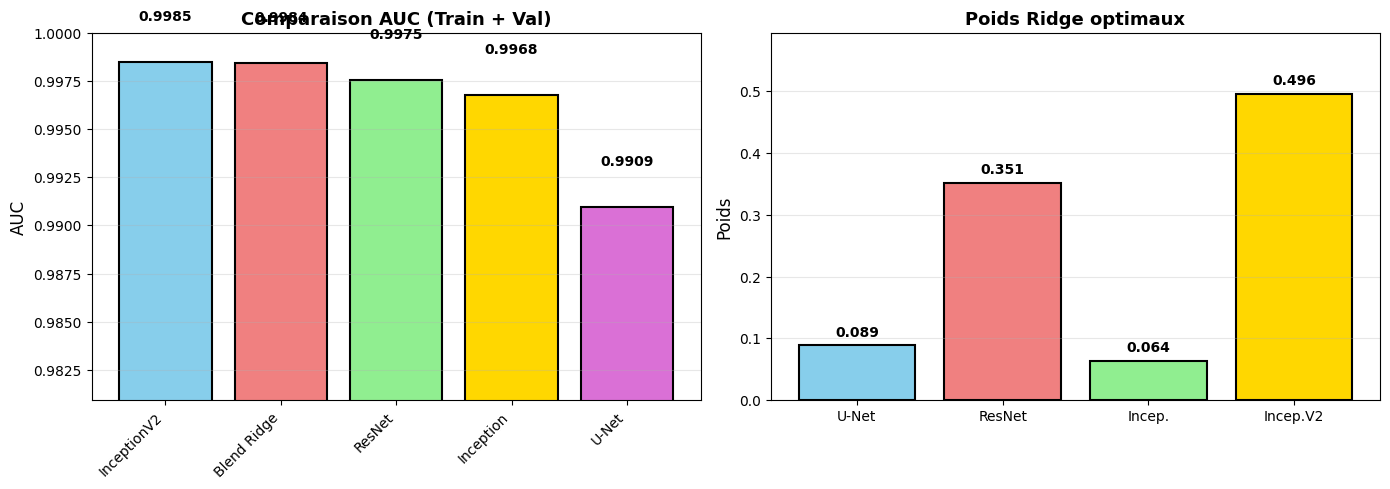


Graphique sauvegarde: final_comparison_trainval.png

GENERATION SUBMISSION

Images test: 529
Strategie: InceptionV2

Mode: MODELE SOLO (InceptionV2)
0/529...
50/529...
100/529...
150/529...
200/529...
250/529...
300/529...
350/529...
400/529...
450/529...
500/529...

FICHIER CREE: submission_inceptionv2.csv
Predictions: 529

Apercu:
        id  prediction
0  img_001    0.999992
1  img_002    0.196140
2  img_003    0.254658
3  img_004    0.303388
4  img_005    0.999997
5  img_006    0.999993
6  img_007    0.999966
7  img_008    0.020033
8  img_009    0.999998
9  img_010    0.999999


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SUBMISSION PRETE !
Strategie utilisee: InceptionV2
AUC sur train+val: 0.998479


In [56]:
# =============================================================================
# EVALUATION COMPLETE - TRAIN + VAL
# =============================================================================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd

print("="*80)
print("EVALUATION SUR TRAIN + VAL (5 STRATEGIES)")
print("="*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =============================================================================
# RECHARGEMENT DES MODELES
# =============================================================================

print("\nChargement des modeles...")

unet = UNet(in_channels=3, dropout_rate=0.5).to(device)
unet.load_state_dict(torch.load('U-Net_best.pt', map_location=device))
unet.eval()

resnet = ResNet(in_channels=3, dropout_rate=0.5).to(device)
resnet.load_state_dict(torch.load('ResNet_best.pt', map_location=device))
resnet.eval()

inception = Inception(in_channels=3, dropout_rate=0.5).to(device)
inception.load_state_dict(torch.load('Inception_best.pt', map_location=device))
inception.eval()

inception_v2 = InceptionV2(in_channels=3, dropout_rate=0.5).to(device)
inception_v2.load_state_dict(torch.load('InceptionV2_best.pt', map_location=device))
inception_v2.eval()

print("Tous les modeles charges !\n")

# =============================================================================
# CHARGEMENT TRAIN + VAL
# =============================================================================

transform = get_transforms(224, augment=False)

# Train
train_dataset = datasets.ImageFolder('data/train', transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Val
val_dataset = datasets.ImageFolder('data/val', transform=transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")
print(f"Total: {len(train_dataset) + len(val_dataset)} images\n")

# =============================================================================
# PREDICTIONS DES 4 MODELES SUR TRAIN + VAL
# =============================================================================

print("="*80)
print("PREDICTIONS EN COURS...")
print("="*80)

def get_predictions(model, loader, name):
    labels, probs = [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            logits = model(imgs)
            p = torch.sigmoid(logits).cpu().numpy().flatten()
            labels.extend(lbls.numpy())
            probs.extend(p)
    return np.array(labels), np.array(probs)

# Train
print("\nSur TRAIN:")
train_labels_u, train_probs_u = get_predictions(unet, train_loader, "U-Net")
print("  U-Net done")
train_labels_r, train_probs_r = get_predictions(resnet, train_loader, "ResNet")
print("  ResNet done")
train_labels_i, train_probs_i = get_predictions(inception, train_loader, "Inception")
print("  Inception done")
train_labels_v2, train_probs_v2 = get_predictions(inception_v2, train_loader, "InceptionV2")
print("  InceptionV2 done")

# Val
print("\nSur VAL:")
val_labels_u, val_probs_u = get_predictions(unet, val_loader, "U-Net")
print("  U-Net done")
val_labels_r, val_probs_r = get_predictions(resnet, val_loader, "ResNet")
print("  ResNet done")
val_labels_i, val_probs_i = get_predictions(inception, val_loader, "Inception")
print("  Inception done")
val_labels_v2, val_probs_v2 = get_predictions(inception_v2, val_loader, "InceptionV2")
print("  InceptionV2 done")

# Concatene train + val
all_labels = np.concatenate([train_labels_u, val_labels_u])
all_probs_u = np.concatenate([train_probs_u, val_probs_u])
all_probs_r = np.concatenate([train_probs_r, val_probs_r])
all_probs_i = np.concatenate([train_probs_i, val_probs_i])
all_probs_v2 = np.concatenate([train_probs_v2, val_probs_v2])

print(f"\nTotal predictions: {len(all_labels)}")

# =============================================================================
# CALCUL DES POIDS RIDGE SUR TRAIN+VAL
# =============================================================================

print(f"\n{'='*80}")
print("CALCUL POIDS RIDGE SUR TRAIN+VAL")
print(f"{'='*80}")

from sklearn.linear_model import RidgeCV

X_blend = np.column_stack([all_probs_u, all_probs_r, all_probs_i, all_probs_v2])

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
ridge = RidgeCV(alphas=alphas, scoring='roc_auc', cv=5)
ridge.fit(X_blend, all_labels)

print(f"\nMeilleur alpha: {ridge.alpha_}")

# Normalise les poids
weights = np.abs(ridge.coef_)
weights = weights / weights.sum()

print(f"\nPoids normalises:")
for i, name in enumerate(['U-Net', 'ResNet', 'Inception', 'InceptionV2']):
    print(f"  {name}: {weights[i]:.4f}")

# Predictions blend
all_probs_blend = X_blend @ weights

# =============================================================================
# COMPARAISON DES 5 STRATEGIES
# =============================================================================

print(f"\n{'='*80}")
print("COMPARAISON DES 5 STRATEGIES")
print(f"{'='*80}\n")

strategies = {
    'U-Net': all_probs_u,
    'ResNet': all_probs_r,
    'Inception': all_probs_i,
    'InceptionV2': all_probs_v2,
    'Blend Ridge': all_probs_blend
}

results = []

for name, probs in strategies.items():
    auc = roc_auc_score(all_labels, probs)
    preds = (probs >= 0.5).astype(int)
    acc = np.mean(preds == all_labels)
    errors = np.sum(preds != all_labels)

    results.append({
        'Strategie': name,
        'AUC': auc,
        'Accuracy': acc,
        'Erreurs': errors,
        'Total': len(all_labels)
    })

results_df = pd.DataFrame(results).sort_values('AUC', ascending=False)

print(results_df.to_string(index=False))

# Meilleure strategie
best_strategy = results_df.iloc[0]['Strategie']
best_auc = results_df.iloc[0]['AUC']

print(f"\n{'='*80}")
print(f"MEILLEURE STRATEGIE: {best_strategy}")
print(f"AUC: {best_auc:.6f}")
print(f"{'='*80}")

# =============================================================================
# VISUALISATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC comparison
ax = axes[0]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'orchid']
bars = ax.bar(range(5), results_df['AUC'], color=colors, edgecolor='black', linewidth=1.5)
ax.set_xticks(range(5))
ax.set_xticklabels(results_df['Strategie'], rotation=45, ha='right')
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Comparaison AUC (Train + Val)', fontweight='bold', fontsize=13)
ax.set_ylim(min(results_df['AUC']) - 0.01, 1.0)
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, auc) in enumerate(zip(bars, results_df['AUC'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{auc:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# Poids Ridge
ax = axes[1]
model_names = ['U-Net', 'ResNet', 'Incep.', 'Incep.V2']
colors_w = ['skyblue', 'lightcoral', 'lightgreen', 'gold']
bars = ax.bar(model_names, weights, color=colors_w, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Poids', fontsize=12)
ax.set_title('Poids Ridge optimaux', fontweight='bold', fontsize=13)
ax.set_ylim(0, max(weights) * 1.2)
ax.grid(True, alpha=0.3, axis='y')

for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{w:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('final_comparison_trainval.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nGraphique sauvegarde: final_comparison_trainval.png")

# =============================================================================
# GENERATION SUBMISSION AVEC LA MEILLEURE STRATEGIE
# =============================================================================

print(f"\n{'='*80}")
print("GENERATION SUBMISSION")
print(f"{'='*80}\n")

from pathlib import Path
from PIL import Image

transform_test = get_transforms(224, augment=False)
test_dir = Path('submission/test_for_students')
image_paths = sorted(test_dir.glob('*.jpeg')) + sorted(test_dir.glob('*.jpg')) + sorted(test_dir.glob('*.png'))

print(f"Images test: {len(image_paths)}")
print(f"Strategie: {best_strategy}\n")

predictions = []

if best_strategy == 'Blend Ridge':
    print("Mode: BLEND RIDGE")
    print("Poids:")
    for i, name in enumerate(['U-Net', 'ResNet', 'Inception', 'InceptionV2']):
        print(f"  {name}: {weights[i]:.4f}")

    with torch.no_grad():
        for i, img_path in enumerate(image_paths):
            if i % 50 == 0:
                print(f'{i}/{len(image_paths)}...')

            image = Image.open(img_path).convert('RGB')
            tensor = transform_test(image).unsqueeze(0).to(device)

            p1 = torch.sigmoid(unet(tensor)).item()
            p2 = torch.sigmoid(resnet(tensor)).item()
            p3 = torch.sigmoid(inception(tensor)).item()
            p4 = torch.sigmoid(inception_v2(tensor)).item()

            prob = weights[0]*p1 + weights[1]*p2 + weights[2]*p3 + weights[3]*p4
            predictions.append({'id': img_path.stem, 'prediction': prob})

    filename = 'submission_blend_ridge.csv'

else:
    print(f"Mode: MODELE SOLO ({best_strategy})")

    if best_strategy == 'U-Net':
        model = unet
    elif best_strategy == 'ResNet':
        model = resnet
    elif best_strategy == 'Inception':
        model = inception
    elif best_strategy == 'InceptionV2':
        model = inception_v2

    with torch.no_grad():
        for i, img_path in enumerate(image_paths):
            if i % 50 == 0:
                print(f'{i}/{len(image_paths)}...')

            image = Image.open(img_path).convert('RGB')
            tensor = transform_test(image).unsqueeze(0).to(device)
            logit = model(tensor)
            prob = torch.sigmoid(logit).item()
            predictions.append({'id': img_path.stem, 'prediction': prob})

    filename = f'submission_{best_strategy.lower().replace(" ", "_")}.csv'

# Sauvegarde
submission_df = pd.DataFrame(predictions)
submission_df.to_csv(filename, index=False)

print(f"\n{'='*80}")
print(f"FICHIER CREE: {filename}")
print(f"{'='*80}")
print(f"Predictions: {len(submission_df)}")
print(f"\nApercu:")
print(submission_df.head(10))

# Telechargement
files.download(filename)

print(f"\n{'='*80}")
print("SUBMISSION PRETE !")
print(f"Strategie utilisee: {best_strategy}")
print(f"AUC sur train+val: {best_auc:.6f}")
print(f"{'='*80}")

In [57]:
print("Mode: BLEND RIDGE")
print("Poids:")
for i, name in enumerate(['U-Net', 'ResNet', 'Inception', 'InceptionV2']):
    print(f"  {name}: {weights[i]:.4f}")

predictions = []
with torch.no_grad():
      for i, img_path in enumerate(image_paths):
          if i % 50 == 0:
              print(f'{i}/{len(image_paths)}...')

          image = Image.open(img_path).convert('RGB')
          tensor = transform_test(image).unsqueeze(0).to(device)

          p1 = torch.sigmoid(unet(tensor)).item()
          p2 = torch.sigmoid(resnet(tensor)).item()
          p3 = torch.sigmoid(inception(tensor)).item()
          p4 = torch.sigmoid(inception_v2(tensor)).item()

          prob = weights[0]*p1 + weights[1]*p2 + weights[2]*p3 + weights[3]*p4
          predictions.append({'id': img_path.stem, 'prediction': prob})

filename = 'submission_blend_ridge.csv'

Mode: BLEND RIDGE
Poids:
  U-Net: 0.0889
  ResNet: 0.3515
  Inception: 0.0640
  InceptionV2: 0.4957
0/529...
50/529...
100/529...
150/529...
200/529...
250/529...
300/529...
350/529...
400/529...
450/529...
500/529...


In [58]:
# Sauvegarde
submission_df = pd.DataFrame(predictions)
submission_df.to_csv(filename, index=False)

print(f"\n{'='*80}")
print(f"FICHIER CREE: {filename}")
print(f"{'='*80}")
print(f"Predictions: {len(submission_df)}")
print(f"\nApercu:")
print(submission_df.head(10))

# Telechargement
files.download(filename)

print(f"\n{'='*80}")
print("SUBMISSION PRETE !")
print(f"Strategie utilisee: {best_strategy}")
print(f"AUC sur train+val: {best_auc:.6f}")
print(f"{'='*80}")


FICHIER CREE: submission_blend_ridge.csv
Predictions: 529

Apercu:
        id  prediction
0  img_001    0.999773
1  img_002    0.197552
2  img_003    0.155679
3  img_004    0.288848
4  img_005    0.999838
5  img_006    0.999890
6  img_007    0.999073
7  img_008    0.079648
8  img_009    0.999673
9  img_010    0.999881


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


SUBMISSION PRETE !
Strategie utilisee: InceptionV2
AUC sur train+val: 0.998479
